# Apples vs Tomatoes - Classical CV + Random Forest

Notebook realizuje pelny pipeline:
- analiza datasetu,
- ekstrakcja cech (GLCM, ksztalt, HSV),
- selekcja cech (SelectKBest),
- klasyfikacja (Random Forest),
- tuning hiperparametrow (GridSearchCV),
- ewaluacja na osobnym zbiorze testowym.

Preprocessing obrazow jest wykorzystywany bez zmian z katalogu `apples_tomatoes_preprocessed/`.

In [17]:
from __future__ import annotations

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from classification.features import LABEL_TO_CLASS, extract_features_matrix, load_train_test
from preprocess.dataset_analysis import analyze_dataset

RANDOM_STATE = 42
ROOT = Path.cwd()
PREPROCESSED_DIR = ROOT / "apples_tomatoes_preprocessed"
ORIGINAL_DIR = ROOT / "apples_tomatoes"
OUTPUT_DIR = ROOT / "classification" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")

## 1) Analiza datasetu

In [18]:
train_df, test_df = load_train_test(PREPROCESSED_DIR)

print(f"Train images: {len(train_df)}")
print(train_df["class_name"].value_counts().sort_index())
print()
print(f"Test images: {len(test_df)}")
print(test_df["class_name"].value_counts().sort_index())

Train images: 294
class_name
apples      164
tomatoes    130
Name: count, dtype: int64

Test images: 97
class_name
apples      54
tomatoes    43
Name: count, dtype: int64


In [19]:
stats = analyze_dataset(ORIGINAL_DIR)
print(stats)

DatasetStats(total_images=391, train_apples=164, train_tomatoes=130, test_apples=54, test_tomatoes=43, by_source={'train/apples/p1': 53, 'train/apples/p2': 57, 'train/apples/p3': 54, 'train/tomatoes/p1': 45, 'train/tomatoes/p2': 29, 'train/tomatoes/p3': 56, 'test/apples/p1': 31, 'test/apples/p2': 10, 'test/apples/p3': 13, 'test/tomatoes/p1': 16, 'test/tomatoes/p2': 14, 'test/tomatoes/p3': 13}, width_range=(100, 335), height_range=(100, 283), unique_sizes=92, small_images_lt_120px=102, brightness_mean=159.8368955626377, brightness_std=48.757262643544685, brightness_min=43.9521, brightness_max=246.3941925925926, class_brightness={'apples': 172.33953546223754, 'tomatoes': 144.082123897246})


Sample preprocessed image size: 224x224


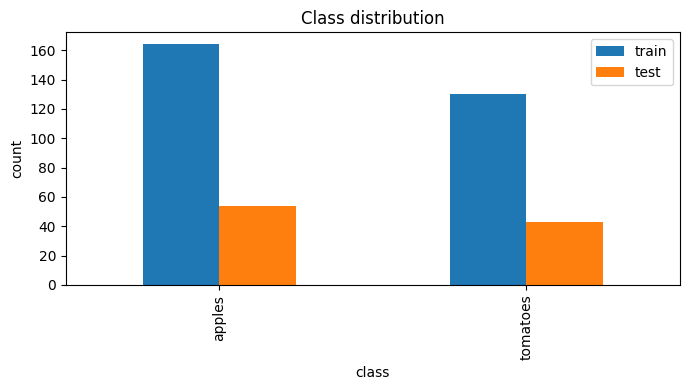

In [20]:
sample_path = Path(train_df.iloc[0]["path"])
sample_img = cv2.imread(str(sample_path))
print(f"Sample preprocessed image size: {sample_img.shape[1]}x{sample_img.shape[0]}")

class_counts = pd.DataFrame(
    {
        "train": train_df["class_name"].value_counts().sort_index(),
        "test": test_df["class_name"].value_counts().sort_index(),
    }
)

ax = class_counts.plot(kind="bar", figsize=(7, 4), title="Class distribution")
ax.set_xlabel("class")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

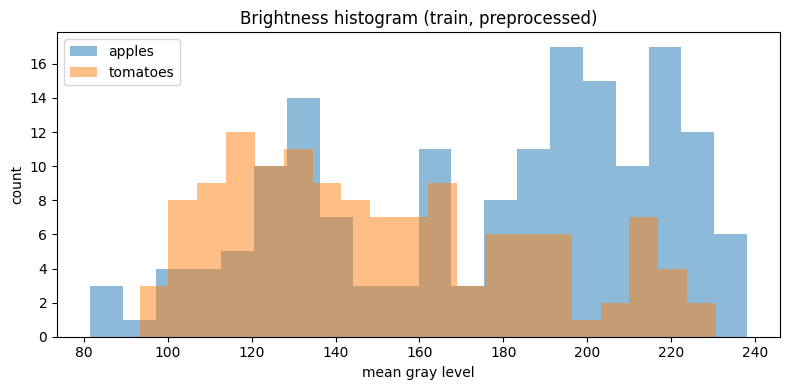

In [21]:
def compute_brightness(paths: pd.Series) -> np.ndarray:
    values: list[float] = []
    for path in paths:
        image = cv2.imread(path)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        values.append(float(gray.mean()))
    return np.array(values, dtype=np.float32)

brightness_train = train_df.copy()
brightness_train["brightness"] = 0.0
for class_name in sorted(brightness_train["class_name"].unique()):
    mask = brightness_train["class_name"] == class_name
    brightness_train.loc[mask, "brightness"] = compute_brightness(brightness_train.loc[mask, "path"])

plt.figure(figsize=(8, 4))
for class_name in sorted(brightness_train["class_name"].unique()):
    vals = brightness_train.loc[brightness_train["class_name"] == class_name, "brightness"]
    plt.hist(vals, bins=20, alpha=0.5, label=class_name)
plt.title("Brightness histogram (train, preprocessed)")
plt.xlabel("mean gray level")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

Krotkie wnioski:
- Zbior jest niewielki i zroznicowany (rozne zrodla p1/p2/p3).
- Klasy sa lekko niezbalansowane (wiecej jabłek niz pomidorow).
- Test ma tylko 97 probek, wiec metryki nalezy interpretowac ostroznie.

## 2) Ekstrakcja cech i trenowanie modelu

In [22]:
all_df = pd.concat([train_df, test_df], ignore_index=True)
cache_path = OUTPUT_DIR / "features_cache.npz"

X_all, feature_names = extract_features_matrix(
    all_df["path"].tolist(),
    cache_path=cache_path,
    use_cache=True,
)

n_train = len(train_df)
X_train = X_all[:n_train]
X_test = X_all[n_train:]
y_train = train_df["label"].to_numpy(dtype=np.int32)
y_test = test_df["label"].to_numpy(dtype=np.int32)

print(f"Feature matrix train: {X_train.shape}")
print(f"Feature matrix test:  {X_test.shape}")
print(f"Number of features:   {len(feature_names)}")

Feature matrix train: (294, 31)
Feature matrix test:  (97, 31)
Number of features:   31


In [23]:
indices = np.arange(len(y_train))
X_fit, X_val, y_fit, y_val, idx_fit, idx_val = train_test_split(
    X_train,
    y_train,
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

print(f"Train-fit: {X_fit.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")


def get_uncorrelated_indices(X: np.ndarray, threshold: float = 0.95) -> list[int]:
    """Return indices of features after removing highly correlated columns."""
    corr = pd.DataFrame(X).corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [int(col) for col in upper.columns if (upper[col] > threshold).any()]
    return [idx for idx in range(X.shape[1]) if idx not in to_drop]


CORR_THRESHOLD = 0.95
keep_idx_fit = get_uncorrelated_indices(X_fit, threshold=CORR_THRESHOLD)

X_fit_corr = X_fit[:, keep_idx_fit]
X_val_corr = X_val[:, keep_idx_fit]
feature_names_corr_fit = [feature_names[i] for i in keep_idx_fit]

print(f"Feature filtering (corr>{CORR_THRESHOLD}): {len(feature_names)} -> {len(feature_names_corr_fit)}")

Train-fit: 235 samples
Validation: 59 samples
Feature filtering (corr>0.95): 31 -> 21


In [24]:
pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif)),
        (
            "clf",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

k_candidates = [8, 12, 16, 20, 25, 31]
k_values = sorted({k for k in k_candidates if k <= X_fit_corr.shape[1]})
if not k_values:
    k_values = [X_fit_corr.shape[1]]

# Grid z naciskiem na redukcje FN dla tomatoes, ale nadal optymalizacja f1_macro.
param_grid = {
    "selector__k": k_values,
    "clf__n_estimators": [200, 300],
    "clf__max_depth": [None],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2],
    "clf__max_features": ["sqrt", 0.5],
    "clf__criterion": ["log_loss"],
    "clf__class_weight": ["balanced", {0: 1, 1: 2.0}, {0: 1, 1: 2.5}],
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid.fit(X_fit_corr, y_fit)

print("Best CV score (f1_macro):", round(grid.best_score_, 4))
print("Best params:")
print(grid.best_params_)

Fitting 10 folds for each of 256 candidates, totalling 2560 fits
Best CV score (f1_macro): 0.7558
Best params:
{'clf__criterion': 'log_loss', 'clf__max_depth': None, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 300, 'selector__k': 20}


In [25]:
best_model = grid.best_estimator_

y_val_prob = best_model.predict_proba(X_val_corr)[:, 1]
y_val_pred_default = (y_val_prob >= 0.5).astype(int)

thresholds = np.linspace(0.30, 0.70, 81)
best_threshold = 0.5
best_threshold_f1 = -1.0

for thr in thresholds:
    y_thr = (y_val_prob >= thr).astype(int)
    f1_thr = f1_score(y_val, y_thr, average="macro")
    if f1_thr > best_threshold_f1:
        best_threshold_f1 = float(f1_thr)
        best_threshold = float(thr)

y_val_pred_tuned = (y_val_prob >= best_threshold).astype(int)

val_comparison = pd.DataFrame(
    {
        "accuracy": [
            accuracy_score(y_val, y_val_pred_default),
            accuracy_score(y_val, y_val_pred_tuned),
        ],
        "f1_macro": [
            f1_score(y_val, y_val_pred_default, average="macro"),
            f1_score(y_val, y_val_pred_tuned, average="macro"),
        ],
        "roc_auc": [
            roc_auc_score(y_val, y_val_prob),
            roc_auc_score(y_val, y_val_prob),
        ],
    },
    index=["default_thr_0.50", f"tuned_thr_{best_threshold:.2f}"],
)

print(f"Best threshold from validation: {best_threshold:.3f}")
val_comparison.round(4)

Best threshold from validation: 0.565


,accuracy,f1_macro,roc_auc
default_thr_0.50,0.7458,0.7431,0.8211
tuned_thr_0.56,0.7627,0.7571,0.8211


In [26]:
# Recompute correlation filtering on full train before final retraining.
keep_idx_train = get_uncorrelated_indices(X_train, threshold=CORR_THRESHOLD)
feature_names_corr_train = [feature_names[i] for i in keep_idx_train]

X_train_corr = X_train[:, keep_idx_train]
X_test_corr = X_test[:, keep_idx_train]

best_k = min(grid.best_params_["selector__k"], X_train_corr.shape[1])

final_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=best_k)),
        (
            "clf",
            RandomForestClassifier(
                class_weight=grid.best_params_["clf__class_weight"],
                random_state=RANDOM_STATE,
                n_jobs=-1,
                n_estimators=grid.best_params_["clf__n_estimators"],
                max_depth=grid.best_params_["clf__max_depth"],
                min_samples_split=grid.best_params_["clf__min_samples_split"],
                min_samples_leaf=grid.best_params_["clf__min_samples_leaf"],
                max_features=grid.best_params_["clf__max_features"],
                criterion=grid.best_params_["clf__criterion"],
            ),
        ),
    ]
)

final_model.fit(X_train_corr, y_train)
print("Final model retrained on full train split.")
print(f"Features after correlation filtering: {len(feature_names_corr_train)}")
print(f"SelectKBest k used in final model: {best_k}")

Final model retrained on full train split.
Features after correlation filtering: 21
SelectKBest k used in final model: 20


## 3) Ewaluacja na zbiorze testowym

In [27]:
y_test_prob = final_model.predict_proba(X_test_corr)[:, 1]
y_test_pred_default = (y_test_prob >= 0.5).astype(int)
y_test_pred_tuned = (y_test_prob >= best_threshold).astype(int)

summary_comparison = pd.DataFrame(
    {
        "accuracy": [
            accuracy_score(y_test, y_test_pred_default),
            accuracy_score(y_test, y_test_pred_tuned),
        ],
        "f1_macro": [
            f1_score(y_test, y_test_pred_default, average="macro"),
            f1_score(y_test, y_test_pred_tuned, average="macro"),
        ],
        "roc_auc": [
            roc_auc_score(y_test, y_test_prob),
            roc_auc_score(y_test, y_test_prob),
        ],
    },
    index=["default_thr_0.50", f"tuned_thr_{best_threshold:.2f}"],
)

# Use tuned threshold for final reporting.
y_test_pred = y_test_pred_tuned

test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average=None,
    labels=[0, 1],
)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average="macro",
)

metrics_table = pd.DataFrame(
    {
        "class": [LABEL_TO_CLASS[0], LABEL_TO_CLASS[1], "macro"],
        "precision": [test_precision[0], test_precision[1], macro_precision],
        "recall": [test_recall[0], test_recall[1], macro_recall],
        "f1": [test_f1[0], test_f1[1], macro_f1],
    }
)

print("Summary metrics (default vs tuned threshold):")
display(summary_comparison.round(4))
print("\nClass metrics (tuned threshold):")
display(metrics_table.round(4))

print("Classification report (tuned threshold):")
print(classification_report(y_test, y_test_pred, target_names=[LABEL_TO_CLASS[0], LABEL_TO_CLASS[1]]))

Summary metrics (default vs tuned threshold):


,accuracy,f1_macro,roc_auc
default_thr_0.50,0.7526,0.7465,0.8361
tuned_thr_0.56,0.7732,0.7541,0.8361



Class metrics (tuned threshold):


,class,precision,recall,f1
0,apples,0.7286,0.9444,0.8226
1,tomatoes,0.8889,0.5581,0.6857
2,macro,0.8087,0.7513,0.7541


Classification report (tuned threshold):
              precision    recall  f1-score   support

      apples       0.73      0.94      0.82        54
    tomatoes       0.89      0.56      0.69        43

    accuracy                           0.77        97
   macro avg       0.81      0.75      0.75        97
weighted avg       0.80      0.77      0.76        97



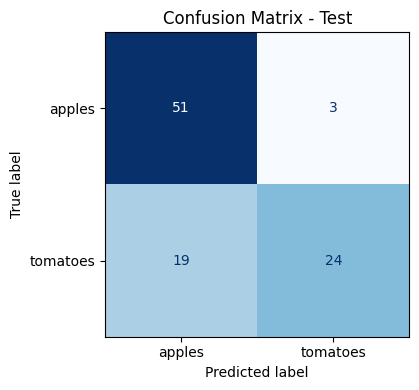

Saved: /home/radek/workspace/studia/6sem/systemy_wizyjne/systemy-wizyjne/classification/output/confusion_matrix.png


In [28]:
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["apples", "tomatoes"]).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
)
ax.set_title("Confusion Matrix - Test")
plt.tight_layout()
cm_path = OUTPUT_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Saved: {cm_path}")

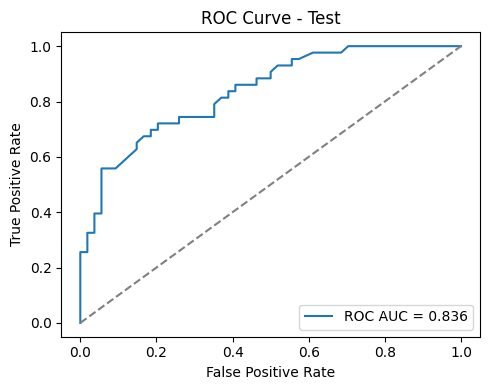

Saved: /home/radek/workspace/studia/6sem/systemy_wizyjne/systemy-wizyjne/classification/output/roc_curve.png


In [29]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc = roc_auc_score(y_test, y_test_prob)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Test")
ax.legend(loc="lower right")
plt.tight_layout()
roc_path = OUTPUT_DIR / "roc_curve.png"
plt.savefig(roc_path, dpi=150)
plt.show()
print(f"Saved: {roc_path}")

Selected features: 20 / 21 (post-correlation)


,feature,importance
3,glcm_correlation_d1,0.115816
1,glcm_homogeneity_d1,0.102562
0,glcm_contrast_d1,0.095990
18,hsv_v_mean,0.081970
14,hsv_h_mean,0.081113
15,hsv_h_std,0.075974
17,hsv_s_std,0.061912
16,hsv_s_mean,0.048921
2,glcm_energy_d1,0.048371
19,hsv_v_std,0.044843


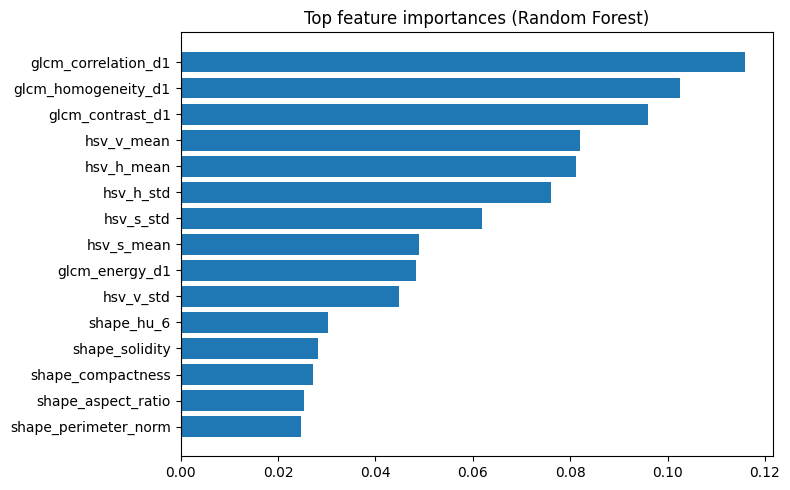

Saved: /home/radek/workspace/studia/6sem/systemy_wizyjne/systemy-wizyjne/classification/output/feature_importance_top15.png


In [30]:
selector = final_model.named_steps["selector"]
rf = final_model.named_steps["clf"]

selected_idx = selector.get_support(indices=True)
selected_features = [feature_names_corr_train[i] for i in selected_idx]
importances = rf.feature_importances_

importance_df = pd.DataFrame(
    {
        "feature": selected_features,
        "importance": importances,
    }
).sort_values("importance", ascending=False)

print(f"Selected features: {len(selected_features)} / {len(feature_names_corr_train)} (post-correlation)")
display(importance_df.head(15))

fig, ax = plt.subplots(figsize=(8, 5))
top_n = min(15, len(importance_df))
plot_df = importance_df.head(top_n).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["importance"])
ax.set_title("Top feature importances (Random Forest)")
plt.tight_layout()
fi_path = OUTPUT_DIR / "feature_importance_top15.png"
plt.savefig(fi_path, dpi=150)
plt.show()
print(f"Saved: {fi_path}")

In [31]:
source_results: list[dict[str, float | str]] = []
for source in sorted(test_df["source"].unique()):
    source_mask = test_df["source"] == source
    idx = np.where(source_mask.to_numpy())[0]
    y_true_src = y_test[idx]
    y_pred_src = y_test_pred[idx]

    source_results.append(
        {
            "source": source,
            "count": int(len(idx)),
            "accuracy": float(accuracy_score(y_true_src, y_pred_src)),
            "f1_macro": float(f1_score(y_true_src, y_pred_src, average="macro")),
        }
    )

source_metrics_df = pd.DataFrame(source_results).sort_values("source")
source_metrics_df

,source,count,accuracy,f1_macro
0,p1,47,0.872340,0.840498
1,p2,24,0.625000,0.619048
2,p3,26,0.730769,0.727136


Misclassified samples: 22 / 97


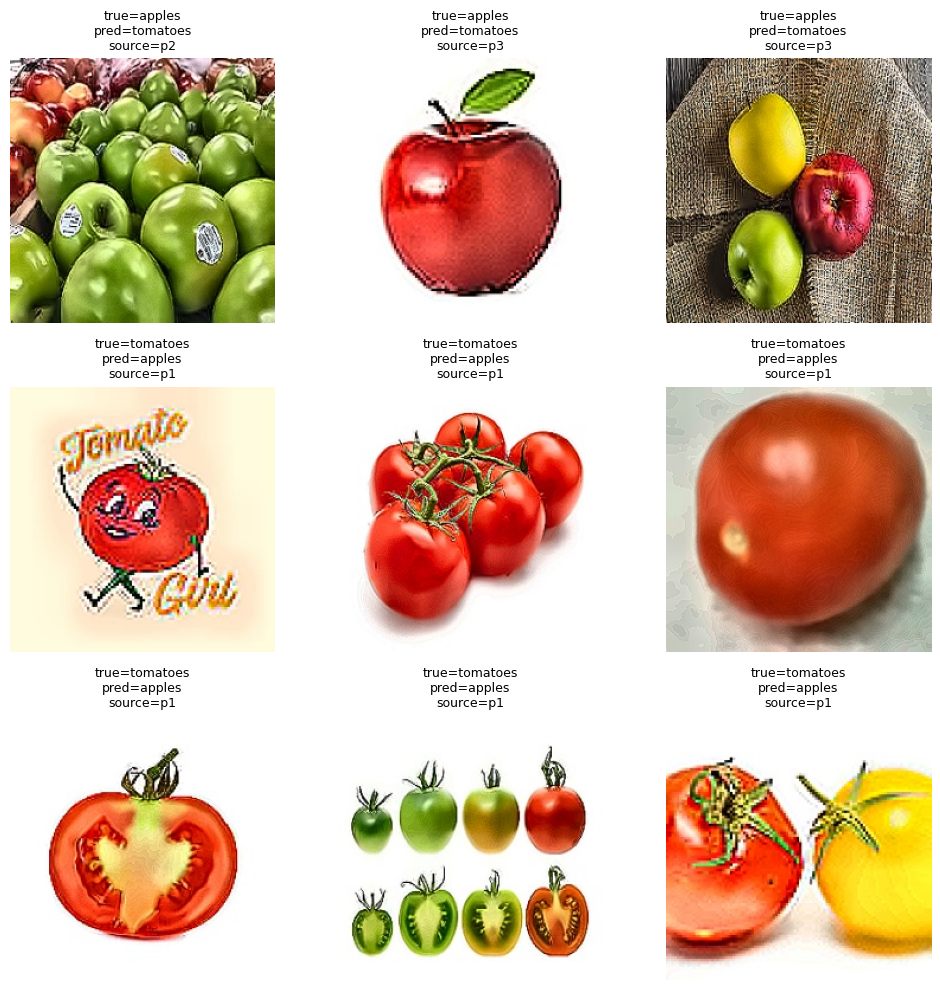

Saved: /home/radek/workspace/studia/6sem/systemy_wizyjne/systemy-wizyjne/classification/output/misclassified_examples.png


In [32]:
error_idx = np.where(y_test_pred != y_test)[0]
print(f"Misclassified samples: {len(error_idx)} / {len(y_test)}")

show_n = min(9, len(error_idx))
if show_n == 0:
    print("No misclassifications to display.")
else:
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.ravel()
    for ax_idx, sample_idx in enumerate(error_idx[:show_n]):
        ax = axes[ax_idx]
        image = cv2.imread(test_df.iloc[sample_idx]["path"])
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        true_label = LABEL_TO_CLASS[int(y_test[sample_idx])]
        pred_label = LABEL_TO_CLASS[int(y_test_pred[sample_idx])]
        source = test_df.iloc[sample_idx]["source"]

        ax.imshow(image_rgb)
        ax.set_title(f"true={true_label}\npred={pred_label}\nsource={source}", fontsize=9)
        ax.axis("off")

    for ax in axes[show_n:]:
        ax.axis("off")

    plt.tight_layout()
    err_path = OUTPUT_DIR / "misclassified_examples.png"
    plt.savefig(err_path, dpi=150)
    plt.show()
    print(f"Saved: {err_path}")

## 4) Krytyczna analiza wynikow (uzupelnij po uruchomieniu)

Do omowienia:
- Jakie sa najsilniejsze cechy po selekcji (GLCM vs ksztalt vs kolor).
- Czy bledy koncentruja sie w konkretnym zrodle (`p1/p2/p3`).
- Jak maly test set (97 obrazow) ogranicza pewnosc metryk.
- Jakie typy obrazow sa najtrudniejsze (np. opakowania, pluszaki, zlozone tlo).
- Jakie dalsze usprawnienia klasyczne mozna dodac bez sieci neuronowych.